In [1]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

PROJECT_ID = "tfm-mercado-laboral-datos"
client = bigquery.Client(project=PROJECT_ID)

query = """
SELECT *
FROM `tfm-mercado-laboral-datos.mercado_laboral_datos.vista_maestra_mercado_laboral`
"""
df = client.query(query).to_dataframe()

print(df.shape)
df.head()

(2163, 26)


,job_id,title,categoria_rol,description,skills_desc,formatted_work_type,formatted_experience_level,remote_allowed,location,views,...,employee_count,follower_count,skills_lista,industrias_lista,beneficios_lista,min_salary,med_salary,max_salary,pay_period,currency
0,3245063922,Data Architect,Data Architect,Request: Data ArchitectLocation: San Francisco...,None,Contract,None,NaN,"San Francisco, CA",7.0,...,304,125864,"Engineering, Information Technology",IT Services and IT Consulting,None,NaN,NaN,NaN,None,None
1,3742692445,Sr Data Engineer with Kafka,Data Engineer,Data Engineer with Kafka (W2 Only)💯% Remote\nM...,None,Full-time,None,1.0,"Austin, TX",39.0,...,3,51,None,IT Services and IT Consulting,None,NaN,NaN,NaN,None,None
2,3780415828,Technical Business Analyst,Business Analyst,We’re actively seeking a Technical Business An...,None,Contract,None,NaN,"Albany, NY",4.0,...,43,807,"Business Development, Sales",Financial Services,None,60000.0,NaN,80000.0,YEARLY,USD
3,3797449314,Cloud Platform/ Big Data Engineer,Data Engineer,About Subaru Research and Development:Do you c...,None,Full-time,Entry level,NaN,"Michigan, United States",7.0,...,76,1093,Engineering,"Motor Vehicle Manufacturing, IT Services and I...","Medical insurance, Vision insurance, Dental in...",NaN,NaN,NaN,None,None
4,3800272386,Data Science Software Engineer,Data Scientist,Company Overview Sovrinti is a full-service en...,None,Full-time,None,1.0,United States,125.0,...,2,39,None,IT Services and IT Consulting,"Vision insurance, Medical insurance, Dental in...",NaN,NaN,NaN,None,None


In [2]:
import plotly.express as px

In [3]:
!pip install -q kaleido==0.2.1
import plotly.io as pio
pio.renderers.default = "png"

In [4]:
texto_ejemplo = df['description'].iloc[0]
print(texto_ejemplo[:1000])

Request: Data ArchitectLocation: San Francisco, CA HybridDuration: Contract Job description:AWS services like EC2, S3, Lambda, Glue, athena, Kinesis datastreams, Kinesis Firehose, etcETL & Data Warehousing concepts with hands-on experience SQL, Redshift, Python , SPARK and JSONAPI-based integration and security Cloud computing and Big data concepts Thanks,sunil.k@saxonglobal.com


In [5]:
import re
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

lematizador = WordNetLemmatizer()
stopwords_ingles = set(stopwords.words('english'))

def preprocesar_texto(texto):
    if texto is None:
        return []
    # separar palabras pegadas tipo "ArchitectLocation" -> "Architect Location"
    texto = re.sub(r'([a-z])([A-Z])', r'\1 \2', texto)
    texto = texto.lower()
    tokens = word_tokenize(texto)
    # nos quedamos con tokens que tengan al menos una letra (para no perder "EC2", "S3"...)
    tokens = [t for t in tokens if any(c.isalpha() for c in t)]
    tokens = [t for t in tokens if t not in stopwords_ingles]
    tokens = [lematizador.lemmatize(t) for t in tokens]
    return tokens

tokens_ejemplo = preprocesar_texto(texto_ejemplo)
print(tokens_ejemplo)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


['request', 'data', 'architect', 'location', 'san', 'francisco', 'ca', 'hybrid', 'duration', 'contract', 'job', 'description', 'aws', 'service', 'like', 'ec2', 's3', 'lambda', 'glue', 'athena', 'kinesis', 'datastreams', 'kinesis', 'firehose', 'etc', 'etl', 'data', 'warehousing', 'concept', 'hands-on', 'experience', 'sql', 'redshift', 'python', 'spark', 'jsonapi-based', 'integration', 'security', 'cloud', 'computing', 'big', 'data', 'concept', 'thanks', 'sunil.k', 'saxonglobal.com']


In [6]:
def limpiar_texto_ligero(texto):
    if texto is None:
        return ""
    texto = re.sub(r'([a-z])([A-Z])', r'\1 \2', texto)
    return texto.lower()

df['descripcion_limpia'] = df['description'].apply(limpiar_texto_ligero)

print(df['descripcion_limpia'].iloc[0][:1000])

request: data architect location: san francisco, ca hybrid duration: contract job description:aws services like ec2, s3, lambda, glue, athena, kinesis datastreams, kinesis firehose, etc etl & data warehousing concepts with hands-on experience sql, redshift, python , spark and jsonapi-based integration and security cloud computing and big data concepts thanks,sunil.k@saxonglobal.com


In [7]:
diccionario_skills = {
    'Python': [r'\bpython\b'],
    'SQL': [r'\bsql\b'],
    'R': [r'\br\b'],
    'Java': [r'\bjava\b'],
    'Scala': [r'\bscala\b'],
    'VBA': [r'\bvba\b'],
    'Excel': [r'\bexcel\b'],
    'Power BI': [r'\bpower\s?bi\b'],
    'Tableau': [r'\btableau\b'],
    'Looker': [r'\blooker\b'],
    'Qlik': [r'\bqlik\b'],
    'SAP': [r'\bsap\b'],
    'Salesforce': [r'\bsalesforce\b'],
    'Alteryx': [r'\balteryx\b'],
    'AWS': [r'\baws\b'],
    'Azure': [r'\bazure\b'],
    'Google Cloud': [r'\bgcp\b', r'\bgoogle cloud\b'],
    'Snowflake': [r'\bsnowflake\b'],
    'Redshift': [r'\bredshift\b'],
    'BigQuery': [r'\bbigquery\b', r'\bbig query\b'],
    'Databricks': [r'\bdatabricks\b'],
    'Spark': [r'\bspark\b'],
    'Hadoop': [r'\bhadoop\b'],
    'Kafka': [r'\bkafka\b'],
    'Airflow': [r'\bairflow\b'],
    'ETL': [r'\betl\b'],
    'MySQL': [r'\bmysql\b'],
    'PostgreSQL': [r'\bpostgresql\b', r'\bpostgres\b'],
    'MongoDB': [r'\bmongodb\b'],
    'NoSQL': [r'\bnosql\b'],
    'Machine Learning': [r'\bmachine learning\b'],
    'Deep Learning': [r'\bdeep learning\b'],
    'TensorFlow': [r'\btensorflow\b'],
    'PyTorch': [r'\bpytorch\b'],
    'Scikit-learn': [r'\bscikit-learn\b', r'\bsklearn\b'],
    'Pandas': [r'\bpandas\b'],
    'NumPy': [r'\bnumpy\b'],
    'Git': [r'\bgit\b'],
    'Docker': [r'\bdocker\b'],
    'Kubernetes': [r'\bkubernetes\b'],
    'Jira': [r'\bjira\b'],
    'Agile': [r'\bagile\b'],
    'Scrum': [r'\bscrum\b'],
    'DAX': [r'\bdax\b'],
}

def detectar_skills(texto, diccionario):
    encontradas = []
    for skill, patrones in diccionario.items():
        for patron in patrones:
            if re.search(patron, texto):
                encontradas.append(skill)
                break
    return encontradas

df['skills_detectadas'] = df['descripcion_limpia'].apply(lambda t: detectar_skills(t, diccionario_skills))

df[['title', 'skills_detectadas']].head(10)

,title,skills_detectadas
0,Data Architect,"[Python, SQL, AWS, Redshift, Spark, ETL]"
1,Sr Data Engineer with Kafka,"[Python, SQL, AWS, Snowflake, Kafka, ETL, Git]"
2,Technical Business Analyst,[SQL]
3,Cloud Platform/ Big Data Engineer,"[Python, R, Java, AWS, Azure, Google Cloud]"
4,Data Science Software Engineer,"[Python, SQL, AWS, Azure, Google Cloud, Snowfl..."
5,Data Engineer/ETL,"[SQL, Java, AWS, Git, Docker]"
6,Data Analyst,"[Python, SQL, R]"
7,Senior Data Engineer/Analyst - Full Time,[]
8,Junior Business Analyst,[]
9,Senior Machine Learning Research Engineer,"[Python, Machine Learning, Deep Learning]"


In [8]:
print(df['descripcion_limpia'].iloc[3])

print(df['descripcion_limpia'].iloc[7])

about subaru research and development:do you care about making social impacts through your job, like eliminating fatal accidents by improving safety driving systems, or reducing carbon emissions by developing new bevs?do your personal interests relate to road trips, going outdoors, off-road driving, hands-on work on cars, or rally and racing? if your answer is yes, then this job is right for you!
subaru r&d is an innovation partner of subaru corporation in japan, and our mission is to serve as a r&d hub of the subaru group. we strive to create products that ignite the hearts of our customers in north america market. we lead and support subaru's next generation vehicle development by researching, prototyping, testing, and analyzing.
general position summary:develops and directs software system tests, programming, and documentation. analyzes north american customer data and technical trends to determine user demands and set target performance goals for future products, and coordinates te

In [9]:
diccionario_skills['R'] = [r'\br\b(?!\s*&\s*d)']
diccionario_skills['C++'] = [r'c\+\+']

df['skills_detectadas'] = df['descripcion_limpia'].apply(lambda t: detectar_skills(t, diccionario_skills))

In [10]:
patron_r = re.compile(r'\br\b(?!\s*&\s*d)')

filas_con_r = df[df['skills_detectadas'].apply(lambda skills: 'R' in skills)]
print(f"Ofertas con 'R' detectada: {len(filas_con_r)}")

for _, fila in filas_con_r.head(15).iterrows():
    m = patron_r.search(fila['descripcion_limpia'])
    inicio = max(0, m.start() - 40)
    fin = min(len(fila['descripcion_limpia']), m.end() + 40)
    print(f"[{fila['title']}] ...{fila['descripcion_limpia'][inicio:fin]}...")

Ofertas con 'R' detectada: 313
[Data Analyst] ... a plus experience with sql, python, or r programming languages is preferred...
[Data Scientist Job] ...tical field using tools such as python, r, sas, matlab familiarity with sql or ot...
[Business Intelligence Developer] ... defending forecasting models in python/r- knowledge of creating and/or maintaini...
[Business Intelligence Engineer II ] ...n statistical analysis packages such as r, sas and matlab- experience using sql t...
[Data Science intern ( Apr 30)] ...nt experience proficient in sql, python/r, data wrangling, data visualization( se...
[Research Data Analyst 1 (75% FTE/Hybrid Opportunity)] ...) experience with statistical software (r, sas, spss, or equivalent), and other c...
[Marketing Analytics - Data Scientist Senior Associate] ...ollowing analytical tools: sas, python, r experience with visualization technique...
[Senior Data Engineer (Property Reinsurance/ Speciality Reinsurance) - 100% Remote] ... data engineers with 

In [11]:
conteo_skills = df['skills_detectadas'].explode().value_counts()
conteo_skills

,count
skills_detectadas,
SQL,1135
Python,943
Machine Learning,517
Agile,491
AWS,426
Excel,404
Azure,382
Power BI,358
ETL,352


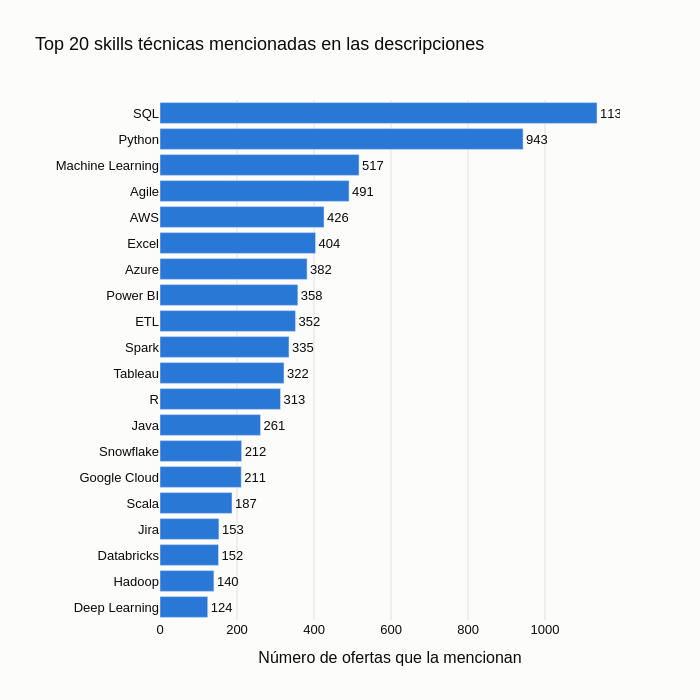

In [12]:
top_20_skills = conteo_skills.head(20).reset_index()
top_20_skills.columns = ['skill', 'num_ofertas']

fig = px.bar(
    top_20_skills.sort_values('num_ofertas'),
    x='num_ofertas',
    y='skill',
    orientation='h',
    text='num_ofertas',
    title='Top 20 skills técnicas mencionadas en las descripciones',
)

fig.update_traces(marker_color='#2a78d6', textposition='outside')
fig.update_layout(
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    xaxis_title='Número de ofertas que la mencionan',
    yaxis_title='',
    font=dict(color='#0b0b0b', size=13),
    margin=dict(l=160),
    height=700,
)
fig.update_xaxes(gridcolor='#e1e0d9', zeroline=False)
fig.update_yaxes(showgrid=False)
fig.show()

In [13]:
orden_roles = df['categoria_rol'].value_counts().sort_values(ascending=False).index.tolist()
df['tokens_descripcion'] = df['description'].apply(preprocesar_texto)
df['texto_lematizado'] = df['tokens_descripcion'].apply(lambda tokens: ' '.join(tokens))

textos_por_rol = df.groupby('categoria_rol')['texto_lematizado'].apply(lambda x: ' '.join(x))
textos_por_rol = textos_por_rol.reindex(orden_roles)

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizador = TfidfVectorizer(max_features=2000, ngram_range=(1, 2), min_df=1)
matriz_tfidf = vectorizador.fit_transform(textos_por_rol)

terminos = vectorizador.get_feature_names_out()

for i, rol in enumerate(textos_por_rol.index):
    fila = matriz_tfidf[i].toarray().flatten()
    top_indices = fila.argsort()[-10:][::-1]
    top_terminos = [(terminos[j], round(fila[j], 3)) for j in top_indices]
    print(f"\n{rol}:")
    for termino, score in top_terminos:
        print(f"  {termino}: {score}")


Business Analyst:
  business: 0.469
  experience: 0.293
  team: 0.183
  requirement: 0.171
  work: 0.165
  process: 0.161
  project: 0.159
  data: 0.158
  skill: 0.132
  analyst: 0.127

Data Analyst:
  data: 0.631
  experience: 0.23
  work: 0.205
  business: 0.176
  team: 0.144
  analysis: 0.119
  skill: 0.117
  analyst: 0.109
  data analyst: 0.097
  ability: 0.095

Data Engineer:
  data: 0.72
  experience: 0.288
  team: 0.138
  work: 0.107
  year: 0.102
  technology: 0.098
  business: 0.092
  engineer: 0.09
  engineering: 0.088
  sql: 0.082

Data Scientist:
  data: 0.533
  experience: 0.29
  science: 0.169
  team: 0.168
  business: 0.157
  work: 0.148
  learning: 0.117
  year: 0.116
  model: 0.114
  data science: 0.108

BI Analyst / Developer:
  data: 0.49
  experience: 0.292
  business: 0.288
  bi: 0.222
  power: 0.186
  team: 0.16
  power bi: 0.148
  work: 0.145
  skill: 0.107
  year: 0.103

Machine Learning Engineer:
  learning: 0.312
  experience: 0.303
  machine: 0.266
  machine

In [14]:
vectorizador = TfidfVectorizer(max_features=2000, ngram_range=(1, 2), min_df=1, max_df=0.8)
matriz_tfidf = vectorizador.fit_transform(textos_por_rol)

terminos = vectorizador.get_feature_names_out()

for i, rol in enumerate(textos_por_rol.index):
    fila = matriz_tfidf[i].toarray().flatten()
    top_indices = fila.argsort()[-10:][::-1]
    top_terminos = [(terminos[j], round(fila[j], 3)) for j in top_indices]
    print(f"\n{rol}:")
    for termino, score in top_terminos:
        print(f"  {termino}: {score}")


Business Analyst:
  user story: 0.241
  cognizant: 0.23
  delta dental: 0.219
  senior business: 0.166
  cgi: 0.16
  business system: 0.155
  delta: 0.137
  year business: 0.137
  fidelity: 0.132
  user acceptance: 0.131

Data Analyst:
  ai community: 0.163
  chatbots: 0.153
  pay pal: 0.144
  pal: 0.144
  train ai: 0.122
  epsilon: 0.122
  evaluate code: 0.119
  coding problem: 0.119
  ai chatbots: 0.119
  script html: 0.119

Data Engineer:
  capital one: 0.457
  fan duel: 0.256
  duel: 0.256
  fan: 0.158
  senior data: 0.132
  glue: 0.123
  publicis: 0.119
  kafka: 0.115
  sapient: 0.113
  publicis sapient: 0.113

Data Scientist:
  capital one: 0.434
  ph: 0.197
  usaa: 0.148
  nlp: 0.126
  deep learning: 0.105
  currently process: 0.09
  language processing: 0.088
  llm: 0.086
  model risk: 0.082
  learning least: 0.08

BI Analyst / Developer:
  bi developer: 0.316
  humana: 0.307
  verizon: 0.279
  dax: 0.208
  bi solution: 0.185
  intelligence developer: 0.166
  bi report: 0.157


In [15]:
def quitar_nombre_empresa(tokens, nombre_empresa):
    if not isinstance(nombre_empresa, str):
        return tokens
    nombre_limpio = limpiar_texto_ligero(nombre_empresa)
    palabras_empresa = set(nombre_limpio.split())
    return [t for t in tokens if t not in palabras_empresa]

df['tokens_sin_empresa'] = df.apply(
    lambda fila: quitar_nombre_empresa(fila['tokens_descripcion'], fila['empresa']),
    axis=1
)
df['texto_sin_empresa'] = df['tokens_sin_empresa'].apply(lambda tokens: ' '.join(tokens))

textos_por_rol_v2 = df.groupby('categoria_rol')['texto_sin_empresa'].apply(lambda x: ' '.join(x))
textos_por_rol_v2 = textos_por_rol_v2.reindex(orden_roles)

vectorizador_v2 = TfidfVectorizer(max_features=2000, ngram_range=(1, 2), min_df=1, max_df=0.8)
matriz_tfidf_v2 = vectorizador_v2.fit_transform(textos_por_rol_v2)

terminos_v2 = vectorizador_v2.get_feature_names_out()

for i, rol in enumerate(textos_por_rol_v2.index):
    fila = matriz_tfidf_v2[i].toarray().flatten()
    top_indices = fila.argsort()[-10:][::-1]
    top_terminos = [(terminos_v2[j], round(fila[j], 3)) for j in top_indices]
    print(f"\n{rol}:")
    for termino, score in top_terminos:
        print(f"  {termino}: {score}")


Business Analyst:
  user story: 0.274
  senior business: 0.188
  business system: 0.174
  year business: 0.155
  user acceptance: 0.148
  visio: 0.136
  acceptance testing: 0.134
  test case: 0.134
  microsoft office: 0.131
  functional specification: 0.122

Data Analyst:
  chatbots: 0.157
  pal: 0.147
  pay pal: 0.147
  train ai: 0.125
  evaluate code: 0.122
  ai chatbots: 0.122
  coding problem: 0.122
  script html: 0.122
  html sql: 0.104
  one programming: 0.093

Data Engineer:
  senior data: 0.181
  glue: 0.168
  kafka: 0.157
  data ingestion: 0.142
  lambda: 0.141
  elt: 0.135
  emr: 0.128
  engineer join: 0.114
  position posted: 0.114
  year data: 0.11

Data Scientist:
  ph: 0.226
  nlp: 0.145
  deep learning: 0.12
  currently process: 0.103
  language processing: 0.101
  llm: 0.098
  model risk: 0.094
  learning least: 0.092
  field science: 0.092
  position posted: 0.091

BI Analyst / Developer:
  bi developer: 0.358
  dax: 0.235
  bi solution: 0.21
  intelligence developer:

In [16]:
!pip install -q wordcloud

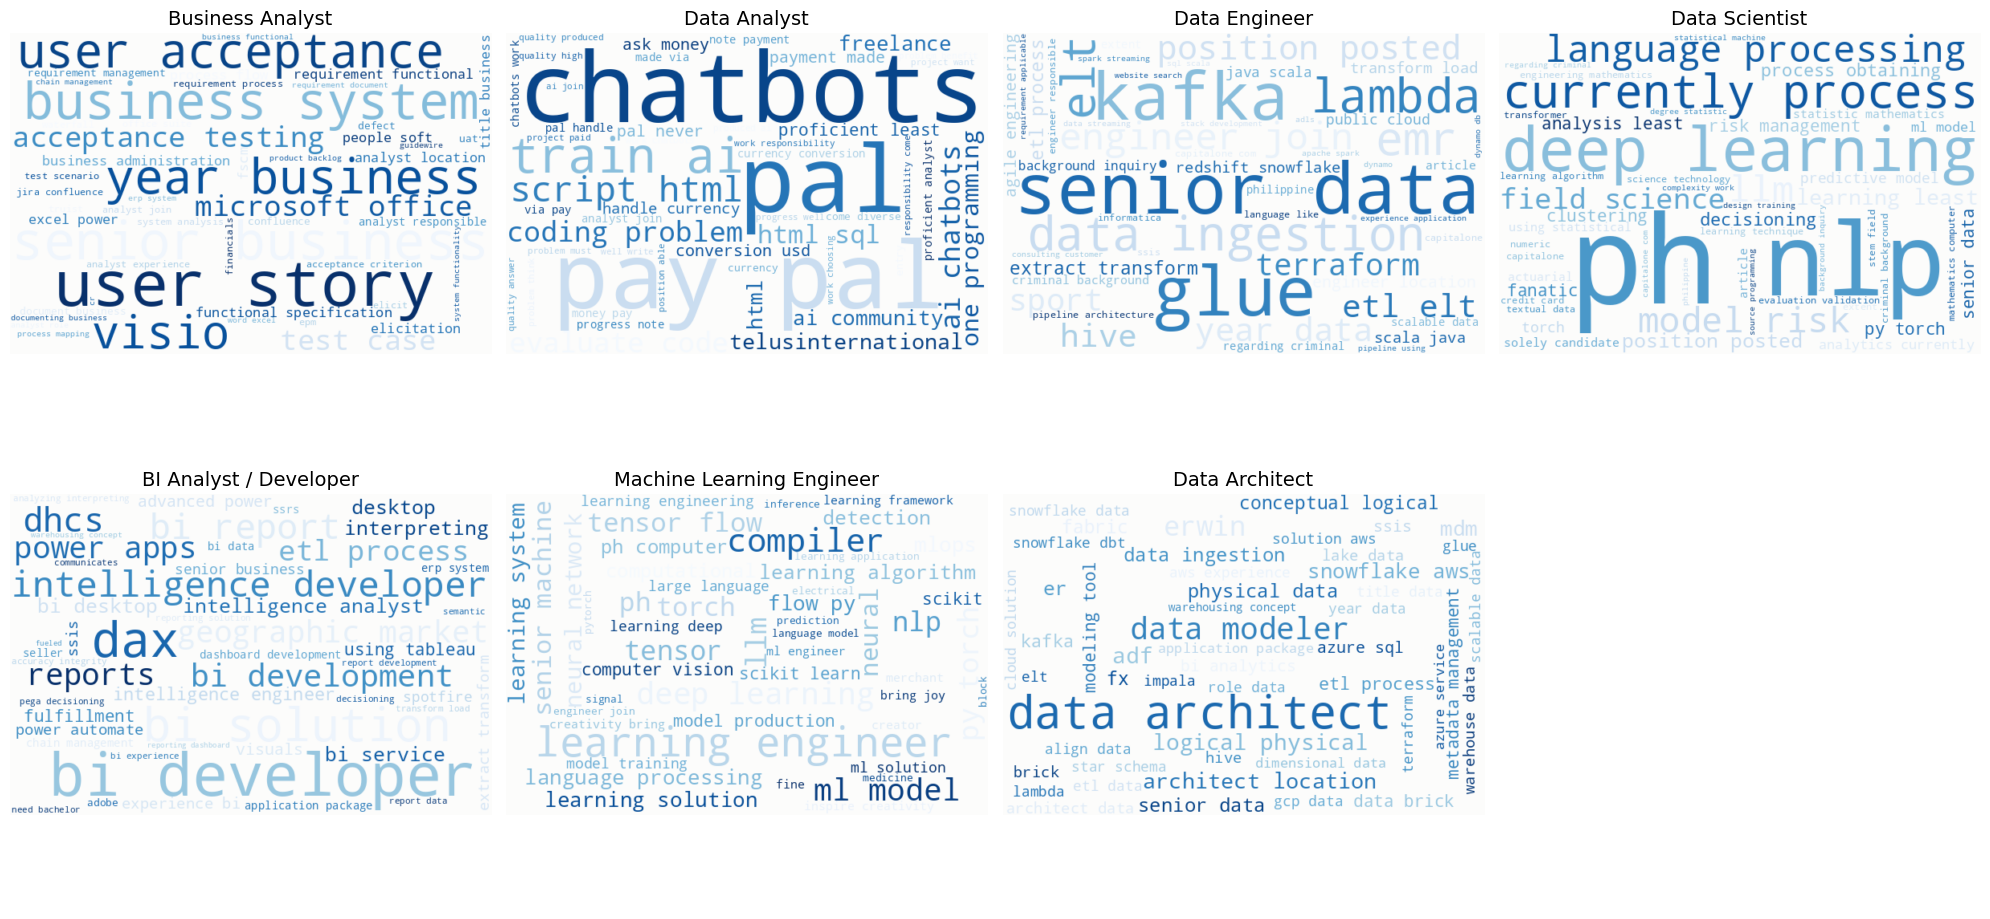

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fig, ejes = plt.subplots(2, 4, figsize=(20, 10))
ejes = ejes.flatten()

for i, rol in enumerate(textos_por_rol_v2.index):
    fila = matriz_tfidf_v2[i].toarray().flatten()
    pesos = {terminos_v2[j]: fila[j] for j in fila.argsort()[-50:] if fila[j] > 0}

    nube = WordCloud(width=600, height=400, background_color='#fcfcfb', colormap='Blues').generate_from_frequencies(pesos)
    ejes[i].imshow(nube, interpolation='bilinear')
    ejes[i].set_title(rol, fontsize=14)
    ejes[i].axis('off')

ejes[-1].axis('off')  # el octavo hueco lo dejamos vacío (solo hay 7 roles)
plt.tight_layout()
plt.savefig('nubes_palabras_roles.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
from google.colab import files
files.download('nubes_palabras_roles.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
df_dedup = df.drop_duplicates(subset='description', keep='first').copy()
print(f"Filas originales: {len(df)}, filas tras quitar duplicados de texto: {len(df_dedup)}")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

X = df_dedup['texto_sin_empresa']
y = df_dedup['categoria_rol']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizador_clasif = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = vectorizador_clasif.fit_transform(X_train)
X_test_tfidf = vectorizador_clasif.transform(X_test)

modelo_logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
modelo_logreg.fit(X_train_tfidf, y_train)

y_pred = modelo_logreg.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))
print(f"F1 macro: {f1_score(y_test, y_pred, average='macro'):.3f}")

Filas originales: 2163, filas tras quitar duplicados de texto: 1943
                           precision    recall  f1-score   support

   BI Analyst / Developer       0.76      0.86      0.81        36
         Business Analyst       0.93      0.94      0.93       106
             Data Analyst       0.80      0.77      0.78        66
           Data Architect       0.79      0.88      0.83        25
            Data Engineer       0.91      0.85      0.88        74
           Data Scientist       0.86      0.74      0.80        58
Machine Learning Engineer       0.76      0.92      0.83        24

                 accuracy                           0.85       389
                macro avg       0.83      0.85      0.84       389
             weighted avg       0.86      0.85      0.85       389

F1 macro: 0.837


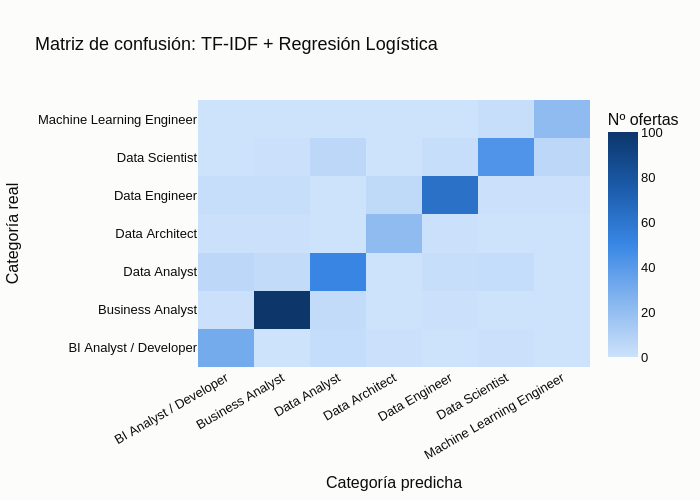

In [20]:
import pandas as pd
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix

etiquetas = sorted(y.unique())
matriz_confusion = confusion_matrix(y_test, y_pred, labels=etiquetas)
matriz_confusion_df = pd.DataFrame(matriz_confusion, index=etiquetas, columns=etiquetas)

colorscale_azul = [
    [0.0, '#cde2fb'],
    [0.25, '#86b6ef'],
    [0.5, '#3987e5'],
    [0.75, '#1c5cab'],
    [1.0, '#0d366b'],
]

fig = go.Figure(data=go.Heatmap(
    z=matriz_confusion_df.values,
    x=matriz_confusion_df.columns,
    y=matriz_confusion_df.index,
    colorscale=colorscale_azul,
    colorbar=dict(title='Nº ofertas'),
    hovertemplate='Real: %{y}<br>Predicho: %{x}<br>%{z} ofertas<extra></extra>',
))

fig.update_layout(
    title='Matriz de confusión: TF-IDF + Regresión Logística',
    xaxis_title='Categoría predicha',
    yaxis_title='Categoría real',
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    font=dict(color='#0b0b0b', size=13),
    margin=dict(l=180, b=120),
)
fig.update_xaxes(tickangle=-30)
fig.show()

In [21]:
!pip install -q transformers datasets evaluate accelerate

import numpy as np
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

etiquetas_unicas = sorted(y.unique())
id2label = {i: etiqueta for i, etiqueta in enumerate(etiquetas_unicas)}
label2id = {etiqueta: i for i, etiqueta in enumerate(etiquetas_unicas)}

df_train = df_dedup.loc[X_train.index].copy()
df_test = df_dedup.loc[X_test.index].copy()

df_train['label'] = df_train['categoria_rol'].map(label2id)
df_test['label'] = df_test['categoria_rol'].map(label2id)

dataset_train = Dataset.from_pandas(df_train[['texto_sin_empresa', 'label']].rename(columns={'texto_sin_empresa': 'text'}))
dataset_test = Dataset.from_pandas(df_test[['texto_sin_empresa', 'label']].rename(columns={'texto_sin_empresa': 'text'}))

MODELO_BASE = "distilbert-base-uncased"
tokenizador = AutoTokenizer.from_pretrained(MODELO_BASE)

def tokenizar(ejemplos):
    return tokenizador(ejemplos['text'], truncation=True, padding='max_length', max_length=256)

dataset_train_tok = dataset_train.map(tokenizar, batched=True)
dataset_test_tok = dataset_test.map(tokenizar, batched=True)

print(dataset_train_tok)
print(dataset_test_tok)

Map:   0%|          | 0/1554 [00:00<?, ? examples/s]

Map:   0%|          | 0/389 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1554
})
Dataset({
    features: ['text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 389
})


In [22]:
from sklearn.metrics import f1_score, accuracy_score

modelo_bert = AutoModelForSequenceClassification.from_pretrained(
    MODELO_BASE,
    num_labels=len(etiquetas_unicas),
    id2label=id2label,
    label2id=label2id,
)

def calcular_metricas(eval_pred):
    logits, labels = eval_pred
    predicciones = np.argmax(logits, axis=1)
    return {
        'f1_macro': f1_score(labels, predicciones, average='macro'),
        'accuracy': accuracy_score(labels, predicciones),
    }

argumentos_entrenamiento = TrainingArguments(
    output_dir='./resultados_bert',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=20,
    report_to='none',
)

entrenador = Trainer(
    model=modelo_bert,
    args=argumentos_entrenamiento,
    train_dataset=dataset_train_tok,
    eval_dataset=dataset_test_tok,
    compute_metrics=calcular_metricas,
)

entrenador.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.854992,0.591453,0.827606,0.850900
2,0.415856,0.381098,0.860892,0.886889
3,0.159252,0.368553,0.863839,0.886889
4,0.135039,0.363454,0.866497,0.889460


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=392, training_loss=0.5466414592703994, metrics={'train_runtime': 182.5311, 'train_samples_per_second': 34.054, 'train_steps_per_second': 2.148, 'total_flos': 411745386221568.0, 'train_loss': 0.5466414592703994, 'epoch': 4.0})

In [23]:
predicciones_bert = entrenador.predict(dataset_test_tok)
y_pred_bert = np.argmax(predicciones_bert.predictions, axis=1)
y_test_bert = predicciones_bert.label_ids

from sklearn.metrics import classification_report

nombres_clases = [id2label[i] for i in range(len(id2label))]
print(classification_report(y_test_bert, y_pred_bert, target_names=nombres_clases))

                           precision    recall  f1-score   support

   BI Analyst / Developer       0.85      0.94      0.89        36
         Business Analyst       0.96      0.96      0.96       106
             Data Analyst       0.85      0.85      0.85        66
           Data Architect       0.90      0.72      0.80        25
            Data Engineer       0.84      0.92      0.88        74
           Data Scientist       0.94      0.84      0.89        58
Machine Learning Engineer       0.79      0.79      0.79        24

                 accuracy                           0.89       389
                macro avg       0.88      0.86      0.87       389
             weighted avg       0.89      0.89      0.89       389



In [24]:
from google.colab import drive
drive.mount('/content/drive')

ruta_guardado = '/content/drive/MyDrive/TFM_modelo_bert_roles'
entrenador.save_model(ruta_guardado)
tokenizador.save_pretrained(ruta_guardado)

print(f"Modelo guardado en: {ruta_guardado}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en: /content/drive/MyDrive/TFM_modelo_bert_roles


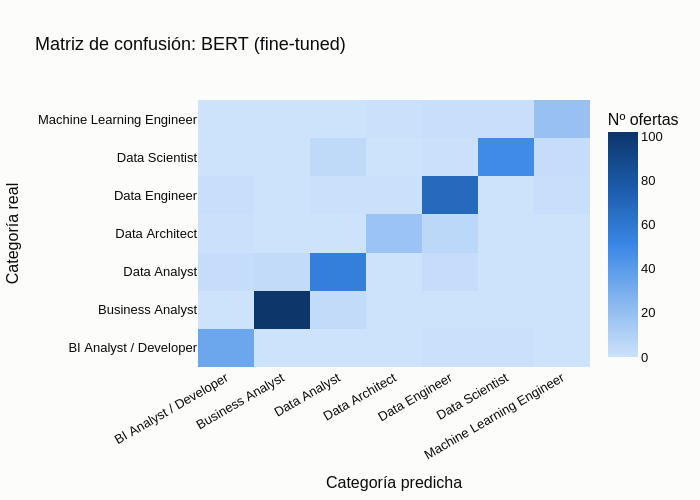

In [25]:
etiquetas_bert = [id2label[i] for i in sorted(id2label.keys())]
matriz_confusion_bert = confusion_matrix(y_test_bert, y_pred_bert, labels=list(range(len(etiquetas_bert))))
matriz_confusion_bert_df = pd.DataFrame(matriz_confusion_bert, index=etiquetas_bert, columns=etiquetas_bert)

fig = go.Figure(data=go.Heatmap(
    z=matriz_confusion_bert_df.values,
    x=matriz_confusion_bert_df.columns,
    y=matriz_confusion_bert_df.index,
    colorscale=colorscale_azul,
    colorbar=dict(title='Nº ofertas'),
    hovertemplate='Real: %{y}<br>Predicho: %{x}<br>%{z} ofertas<extra></extra>',
))

fig.update_layout(
    title='Matriz de confusión: BERT (fine-tuned)',
    xaxis_title='Categoría predicha',
    yaxis_title='Categoría real',
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    font=dict(color='#0b0b0b', size=13),
    margin=dict(l=180, b=120),
)
fig.update_xaxes(tickangle=-30)
fig.show()

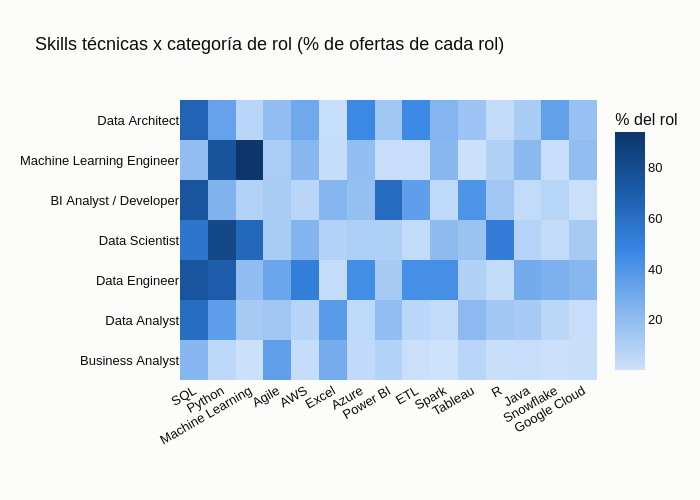

In [26]:
df_skills_explode = df[['categoria_rol', 'skills_detectadas']].explode('skills_detectadas').dropna()

top_15_skills = conteo_skills.head(15).index.tolist()
df_skills_top = df_skills_explode[df_skills_explode['skills_detectadas'].isin(top_15_skills)]

tabla_skill_rol = pd.crosstab(df_skills_top['categoria_rol'], df_skills_top['skills_detectadas'])
tabla_skill_rol = tabla_skill_rol.reindex(index=orden_roles, columns=top_15_skills)

total_por_rol_v2 = df.groupby('categoria_rol').size()
tabla_skill_rol_pct = tabla_skill_rol.div(total_por_rol_v2.reindex(orden_roles), axis=0) * 100
tabla_skill_rol_pct = tabla_skill_rol_pct.round(1)

fig = go.Figure(data=go.Heatmap(
    z=tabla_skill_rol_pct.values,
    x=tabla_skill_rol_pct.columns,
    y=tabla_skill_rol_pct.index,
    colorscale=colorscale_azul,
    colorbar=dict(title='% del rol'),
    hovertemplate='%{y} - %{x}: %{z}%<extra></extra>',
))

fig.update_layout(
    title='Skills técnicas x categoría de rol (% de ofertas de cada rol)',
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    font=dict(color='#0b0b0b', size=13),
    margin=dict(l=180, b=120),
)
fig.update_xaxes(tickangle=-30)
fig.show()

In [27]:
from sklearn.model_selection import StratifiedKFold

X_full = df_dedup['texto_sin_empresa']
y_full = df_dedup['categoria_rol']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores_logreg = []

for fold, (idx_train, idx_test) in enumerate(skf.split(X_full, y_full), start=1):
    X_tr, X_te = X_full.iloc[idx_train], X_full.iloc[idx_test]
    y_tr, y_te = y_full.iloc[idx_train], y_full.iloc[idx_test]

    vectorizador_cv = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
    X_tr_tfidf = vectorizador_cv.fit_transform(X_tr)
    X_te_tfidf = vectorizador_cv.transform(X_te)

    modelo_cv = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    modelo_cv.fit(X_tr_tfidf, y_tr)
    y_pred_cv = modelo_cv.predict(X_te_tfidf)

    f1_fold = f1_score(y_te, y_pred_cv, average='macro')
    f1_scores_logreg.append(f1_fold)
    print(f"Fold {fold}: F1 macro = {f1_fold:.3f}")

f1_scores_logreg = np.array(f1_scores_logreg)
print(f"\nF1 macro (5-fold CV): {f1_scores_logreg.mean():.3f} ± {f1_scores_logreg.std():.3f}")

Fold 1: F1 macro = 0.839
Fold 2: F1 macro = 0.836
Fold 3: F1 macro = 0.867
Fold 4: F1 macro = 0.843
Fold 5: F1 macro = 0.834

F1 macro (5-fold CV): 0.844 ± 0.012


In [28]:
df_full = df_dedup.copy()
df_full['label'] = df_full['categoria_rol'].map(label2id)

skf_bert = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores_bert = []

for fold, (idx_train, idx_test) in enumerate(skf_bert.split(df_full, df_full['label']), start=1):
    print(f"\n--- Fold {fold} ---")

    df_tr_fold = df_full.iloc[idx_train]
    df_te_fold = df_full.iloc[idx_test]

    ds_train_fold = Dataset.from_pandas(df_tr_fold[['texto_sin_empresa', 'label']].rename(columns={'texto_sin_empresa': 'text'}))
    ds_test_fold = Dataset.from_pandas(df_te_fold[['texto_sin_empresa', 'label']].rename(columns={'texto_sin_empresa': 'text'}))

    ds_train_fold_tok = ds_train_fold.map(tokenizar, batched=True)
    ds_test_fold_tok = ds_test_fold.map(tokenizar, batched=True)

    modelo_fold = AutoModelForSequenceClassification.from_pretrained(
        MODELO_BASE,
        num_labels=len(etiquetas_unicas),
        id2label=id2label,
        label2id=label2id,
    )

    argumentos_fold = TrainingArguments(
        output_dir=f'./resultados_bert_fold{fold}',
        num_train_epochs=4,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        eval_strategy='epoch',
        save_strategy='no',
        logging_steps=50,
        report_to='none',
    )

    entrenador_fold = Trainer(
        model=modelo_fold,
        args=argumentos_fold,
        train_dataset=ds_train_fold_tok,
        eval_dataset=ds_test_fold_tok,
        compute_metrics=calcular_metricas,
    )

    entrenador_fold.train()
    resultado_fold = entrenador_fold.evaluate()
    f1_fold = resultado_fold['eval_f1_macro']
    f1_scores_bert.append(f1_fold)
    print(f"Fold {fold}: F1 macro = {f1_fold:.3f}")

f1_scores_bert = np.array(f1_scores_bert)
print(f"\nF1 macro BERT (5-fold CV): {f1_scores_bert.mean():.3f} ± {f1_scores_bert.std():.3f}")


--- Fold 1 ---


Map:   0%|          | 0/1554 [00:00<?, ? examples/s]

Map:   0%|          | 0/389 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,1.690507,0.717881,0.625825,0.757732
2,0.518551,0.337905,0.917341,0.920103
3,0.292161,0.382906,0.902252,0.902062
4,0.172440,0.345945,0.921865,0.917526


Training Loss,Validation Loss,Epoch,F1 Macro,Accuracy
0.172440,0.345945,4,0.921865,0.917526


Fold 5: F1 macro = 0.922

F1 macro BERT (5-fold CV): 0.890 ± 0.023


In [29]:
!nvidia-smi

Sun Aug 16 11:38:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             65W /   70W |    3145MiB /  15360MiB |     97%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----